Dataset Shape: (20640, 8)
Feature Names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


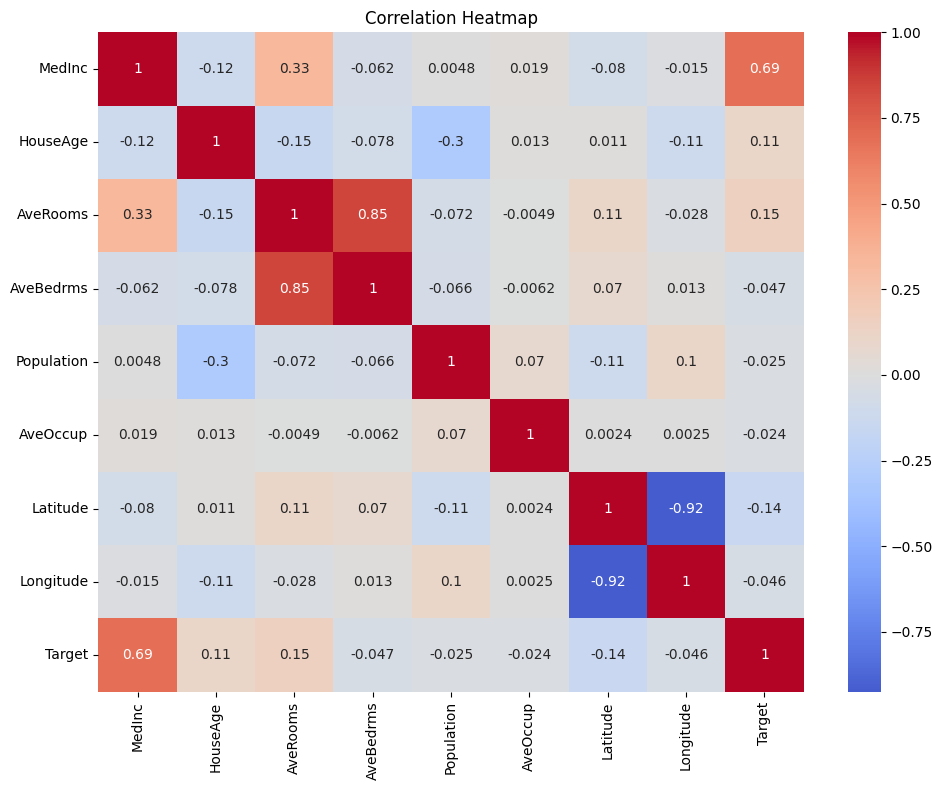

[0.48485857 0.62249739 0.64621047 0.5431996  0.49468484]
[0.69631786 0.78898504 0.80387217 0.73702076 0.70333835]


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# Load dataset
housing = fetch_california_housing()
X = housing.data
y = housing.target
feature_names = housing.feature_names

print("Dataset Shape:", X.shape)
print("Feature Names:", feature_names)

# Analysis 1: Correlation Heatmap
plt.figure(figsize=(10, 8))
df = pd.DataFrame(X, columns=feature_names)
df['Target'] = y
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# Preprocessing: Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Linear Regression with 5-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = LinearRegression()
mse_scores = -cross_val_score(LinearRegression(), X, y,
                             scoring='neg_mean_squared_error', cv=5)

# Calculate RMSE from MSE
rmse_scores = np.sqrt(mse_scores)
print(mse_scores)
print(rmse_scores)


Applying naive bayes , decision tree classifier on kfold and cross validation model

Dataset Shape: (150, 4)
Classes: ['setosa' 'versicolor' 'virginica']


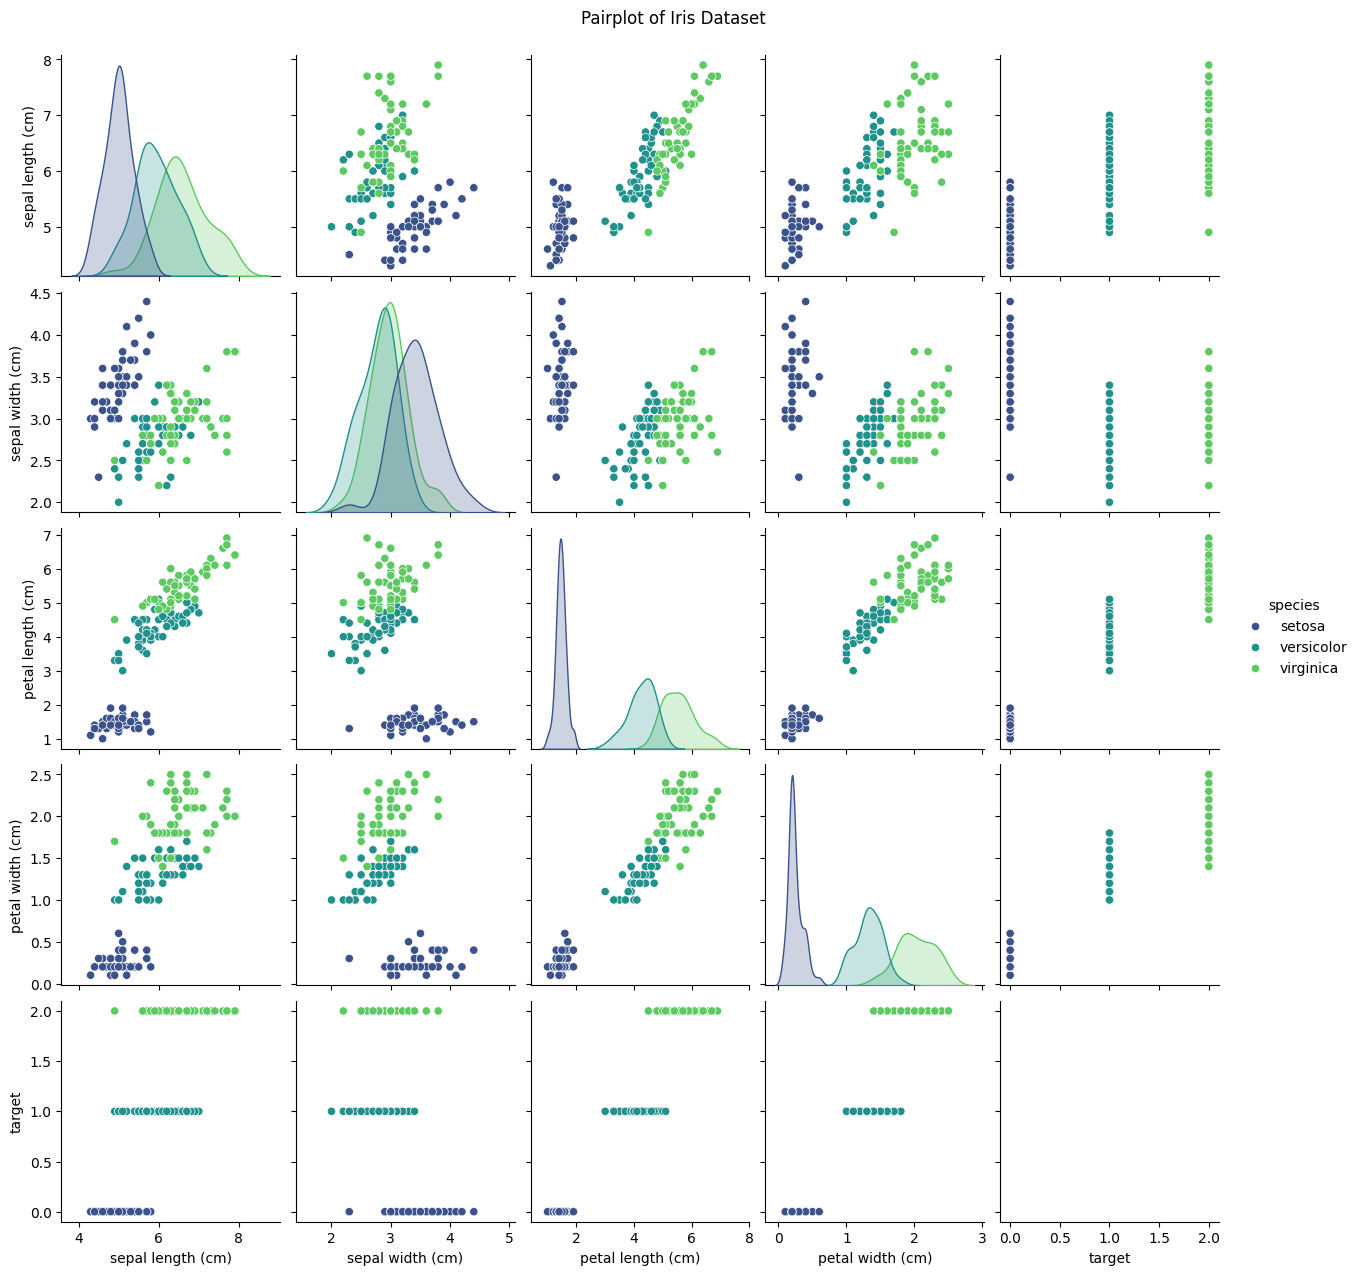

SITUATION A: 80-20 Random Split

Naive Bayes Results:
Accuracy:  0.9667
Precision: 0.9697
Recall:    0.9667
F1-Score:  0.9666

Decision Tree Results:
Accuracy:  0.9333
Precision: 0.9333
Recall:    0.9333
F1-Score:  0.9333

SITUATION B: 5-Fold Cross Validation

Naive Bayes (5-Fold CV) Results:
Accuracy:  0.9600 (+/- 0.0249)
Precision: 0.9639 (+/- 0.0228)
Recall:    0.9600 (+/- 0.0249)
F1-Score:  0.9599 (+/- 0.0249)

Decision Tree (5-Fold CV) Results:
Accuracy:  0.9533 (+/- 0.0267)
Precision: 0.9587 (+/- 0.0238)
Recall:    0.9533 (+/- 0.0267)
F1-Score:  0.9532 (+/- 0.0267)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print("Dataset Shape:", X.shape)
print("Classes:", target_names)

# Analysis 2: Pairplot
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df['species'] = [target_names[i] for i in y]


sns.pairplot(df, hue='species', palette='viridis')
plt.suptitle('Pairplot of Iris Dataset', y=1.02)
plt.show()

# Preprocessing: Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Situation A: Random Sampling (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Initialize classifiers
nb_classifier = GaussianNB()
dt_classifier = DecisionTreeClassifier(random_state=42)

print("SITUATION A: 80-20 Random Split")
print("="*60)

# Train and evaluate Naive Bayes
nb_classifier.fit(X_train, y_train)
y_pred_nb = nb_classifier.predict(X_test)

nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb, average='weighted')
nb_recall = recall_score(y_test, y_pred_nb, average='weighted')
nb_f1 = f1_score(y_test, y_pred_nb, average='weighted')

print("\nNaive Bayes Results:")
print(f"Accuracy:  {nb_accuracy:.4f}")
print(f"Precision: {nb_precision:.4f}")
print(f"Recall:    {nb_recall:.4f}")
print(f"F1-Score:  {nb_f1:.4f}")

# Train and evaluate Decision Tree
dt_classifier.fit(X_train, y_train)
y_pred_dt = dt_classifier.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt, average='weighted')
dt_recall = recall_score(y_test, y_pred_dt, average='weighted')
dt_f1 = f1_score(y_test, y_pred_dt, average='weighted')

print("\nDecision Tree Results:")
print(f"Accuracy:  {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall:    {dt_recall:.4f}")
print(f"F1-Score:  {dt_f1:.4f}")

# Situation B: 5-Fold Cross Validation
print("\n" + "="*60)
print("SITUATION B: 5-Fold Cross Validation")
print("="*60)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Naive Bayes with 5-Fold CV
nb_cv_accuracy = cross_val_score(nb_classifier, X_scaled, y, cv=kf, scoring='accuracy')
nb_cv_precision = cross_val_score(nb_classifier, X_scaled, y, cv=kf, scoring='precision_weighted')
nb_cv_recall = cross_val_score(nb_classifier, X_scaled, y, cv=kf, scoring='recall_weighted')
nb_cv_f1 = cross_val_score(nb_classifier, X_scaled, y, cv=kf, scoring='f1_weighted')

print("\nNaive Bayes (5-Fold CV) Results:")
print(f"Accuracy:  {np.mean(nb_cv_accuracy):.4f} (+/- {np.std(nb_cv_accuracy):.4f})")
print(f"Precision: {np.mean(nb_cv_precision):.4f} (+/- {np.std(nb_cv_precision):.4f})")
print(f"Recall:    {np.mean(nb_cv_recall):.4f} (+/- {np.std(nb_cv_recall):.4f})")
print(f"F1-Score:  {np.mean(nb_cv_f1):.4f} (+/- {np.std(nb_cv_f1):.4f})")

# Decision Tree with 5-Fold CV
dt_cv_accuracy = cross_val_score(dt_classifier, X_scaled, y, cv=kf, scoring='accuracy')
dt_cv_precision = cross_val_score(dt_classifier, X_scaled, y, cv=kf, scoring='precision_weighted')
dt_cv_recall = cross_val_score(dt_classifier, X_scaled, y, cv=kf, scoring='recall_weighted')
dt_cv_f1 = cross_val_score(dt_classifier, X_scaled, y, cv=kf, scoring='f1_weighted')

print("\nDecision Tree (5-Fold CV) Results:")
print(f"Accuracy:  {np.mean(dt_cv_accuracy):.4f} (+/- {np.std(dt_cv_accuracy):.4f})")
print(f"Precision: {np.mean(dt_cv_precision):.4f} (+/- {np.std(dt_cv_precision):.4f})")
print(f"Recall:    {np.mean(dt_cv_recall):.4f} (+/- {np.std(dt_cv_recall):.4f})")
print(f"F1-Score:  {np.mean(dt_cv_f1):.4f} (+/- {np.std(dt_cv_f1):.4f})")

Wine Dataset analysis using supervised learning approaches

Dataset Shape: (178, 13)
Classes: ['class_0' 'class_1' 'class_2']


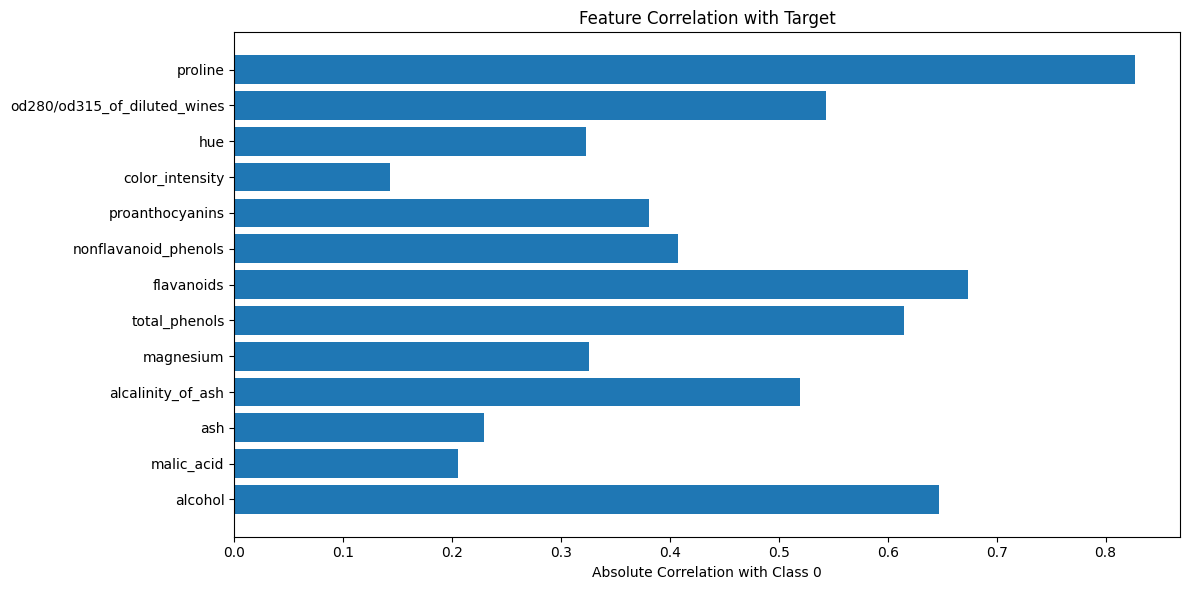

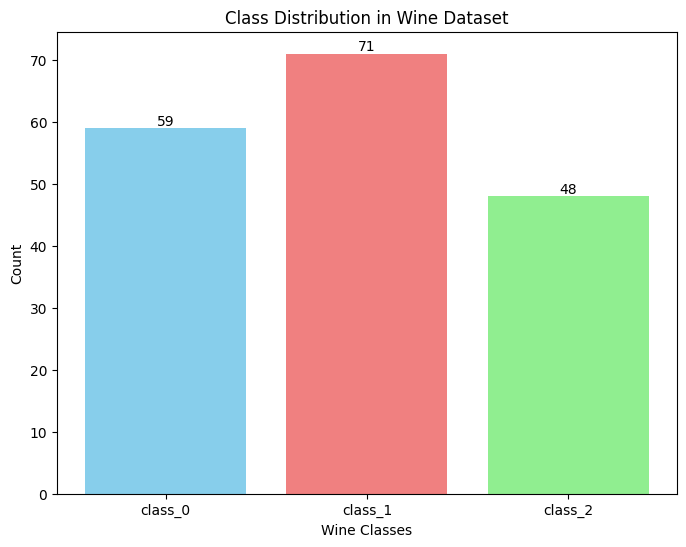

SITUATION A: 70-30 Random Split

K-Nearest Neighbors Results:
Accuracy:  0.9444
Precision: 0.9537
Recall:    0.9444
F1-Score:  0.9448

Decision Tree Results:
Accuracy:  0.9630
Precision: 0.9662
Recall:    0.9630
F1-Score:  0.9632

SITUATION B: 6-Fold Cross Validation

K-Nearest Neighbors (6-Fold CV) Results:
Accuracy:  0.9605 (+/- 0.0233)
Precision: 0.9654 (+/- 0.0198)
Recall:    0.9605 (+/- 0.0233)
F1-Score:  0.9604 (+/- 0.0235)

Decision Tree (6-Fold CV) Results:
Accuracy:  0.8983 (+/- 0.0491)
Precision: 0.9042 (+/- 0.0484)
Recall:    0.8983 (+/- 0.0491)
F1-Score:  0.8980 (+/- 0.0490)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load dataset
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names
target_names = wine.target_names

print("Dataset Shape:", X.shape)
print("Classes:", target_names)

# Preprocessing: Standardization (important for KNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Situation A: Random Sampling (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

# Initialize classifiers
knn_classifier = KNeighborsClassifier(n_neighbors=5)
dt_classifier = DecisionTreeClassifier(random_state=42)

print("SITUATION A: 70-30 Random Split")
print("="*60)

# Train and evaluate KNN
knn_classifier.fit(X_train, y_train)
y_pred_knn = knn_classifier.predict(X_test)

knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn, average='weighted')
knn_recall = recall_score(y_test, y_pred_knn, average='weighted')
knn_f1 = f1_score(y_test, y_pred_knn, average='weighted')

print("\nK-Nearest Neighbors Results:")
print(f"Accuracy:  {knn_accuracy:.4f}")
print(f"Precision: {knn_precision:.4f}")
print(f"Recall:    {knn_recall:.4f}")
print(f"F1-Score:  {knn_f1:.4f}")

# Train and evaluate Decision Tree
dt_classifier.fit(X_train, y_train)
y_pred_dt = dt_classifier.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt, average='weighted')
dt_recall = recall_score(y_test, y_pred_dt, average='weighted')
dt_f1 = f1_score(y_test, y_pred_dt, average='weighted')

print("\nDecision Tree Results:")
print(f"Accuracy:  {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall:    {dt_recall:.4f}")
print(f"F1-Score:  {dt_f1:.4f}")

# Situation B: 6-Fold Cross Validation
print("\n" + "="*60)
print("SITUATION B: 6-Fold Cross Validation")
print("="*60)

kf = KFold(n_splits=6, shuffle=True, random_state=42)

# KNN with 6-Fold CV
knn_cv_accuracy = cross_val_score(knn_classifier, X_scaled, y, cv=kf, scoring='accuracy')
knn_cv_precision = cross_val_score(knn_classifier, X_scaled, y, cv=kf, scoring='precision_weighted')
knn_cv_recall = cross_val_score(knn_classifier, X_scaled, y, cv=kf, scoring='recall_weighted')
knn_cv_f1 = cross_val_score(knn_classifier, X_scaled, y, cv=kf, scoring='f1_weighted')

print("\nK-Nearest Neighbors (6-Fold CV) Results:")
print(f"Accuracy:  {np.mean(knn_cv_accuracy):.4f} (+/- {np.std(knn_cv_accuracy):.4f})")
print(f"Precision: {np.mean(knn_cv_precision):.4f} (+/- {np.std(knn_cv_precision):.4f})")
print(f"Recall:    {np.mean(knn_cv_recall):.4f} (+/- {np.std(knn_cv_recall):.4f})")
print(f"F1-Score:  {np.mean(knn_cv_f1):.4f} (+/- {np.std(knn_cv_f1):.4f})")

# Decision Tree with 6-Fold CV
dt_cv_accuracy = cross_val_score(dt_classifier, X_scaled, y, cv=kf, scoring='accuracy')
dt_cv_precision = cross_val_score(dt_classifier, X_scaled, y, cv=kf, scoring='precision_weighted')
dt_cv_recall = cross_val_score(dt_classifier, X_scaled, y, cv=kf, scoring='recall_weighted')
dt_cv_f1 = cross_val_score(dt_classifier, X_scaled, y, cv=kf, scoring='f1_weighted')

print("\nDecision Tree (6-Fold CV) Results:")
print(f"Accuracy:  {np.mean(dt_cv_accuracy):.4f} (+/- {np.std(dt_cv_accuracy):.4f})")
print(f"Precision: {np.mean(dt_cv_precision):.4f} (+/- {np.std(dt_cv_precision):.4f})")
print(f"Recall:    {np.mean(dt_cv_recall):.4f} (+/- {np.std(dt_cv_recall):.4f})")
print(f"F1-Score:  {np.mean(dt_cv_f1):.4f} (+/- {np.std(dt_cv_f1):.4f})")

Dataset Shape: (569, 30)
Classes: ['malignant' 'benign']


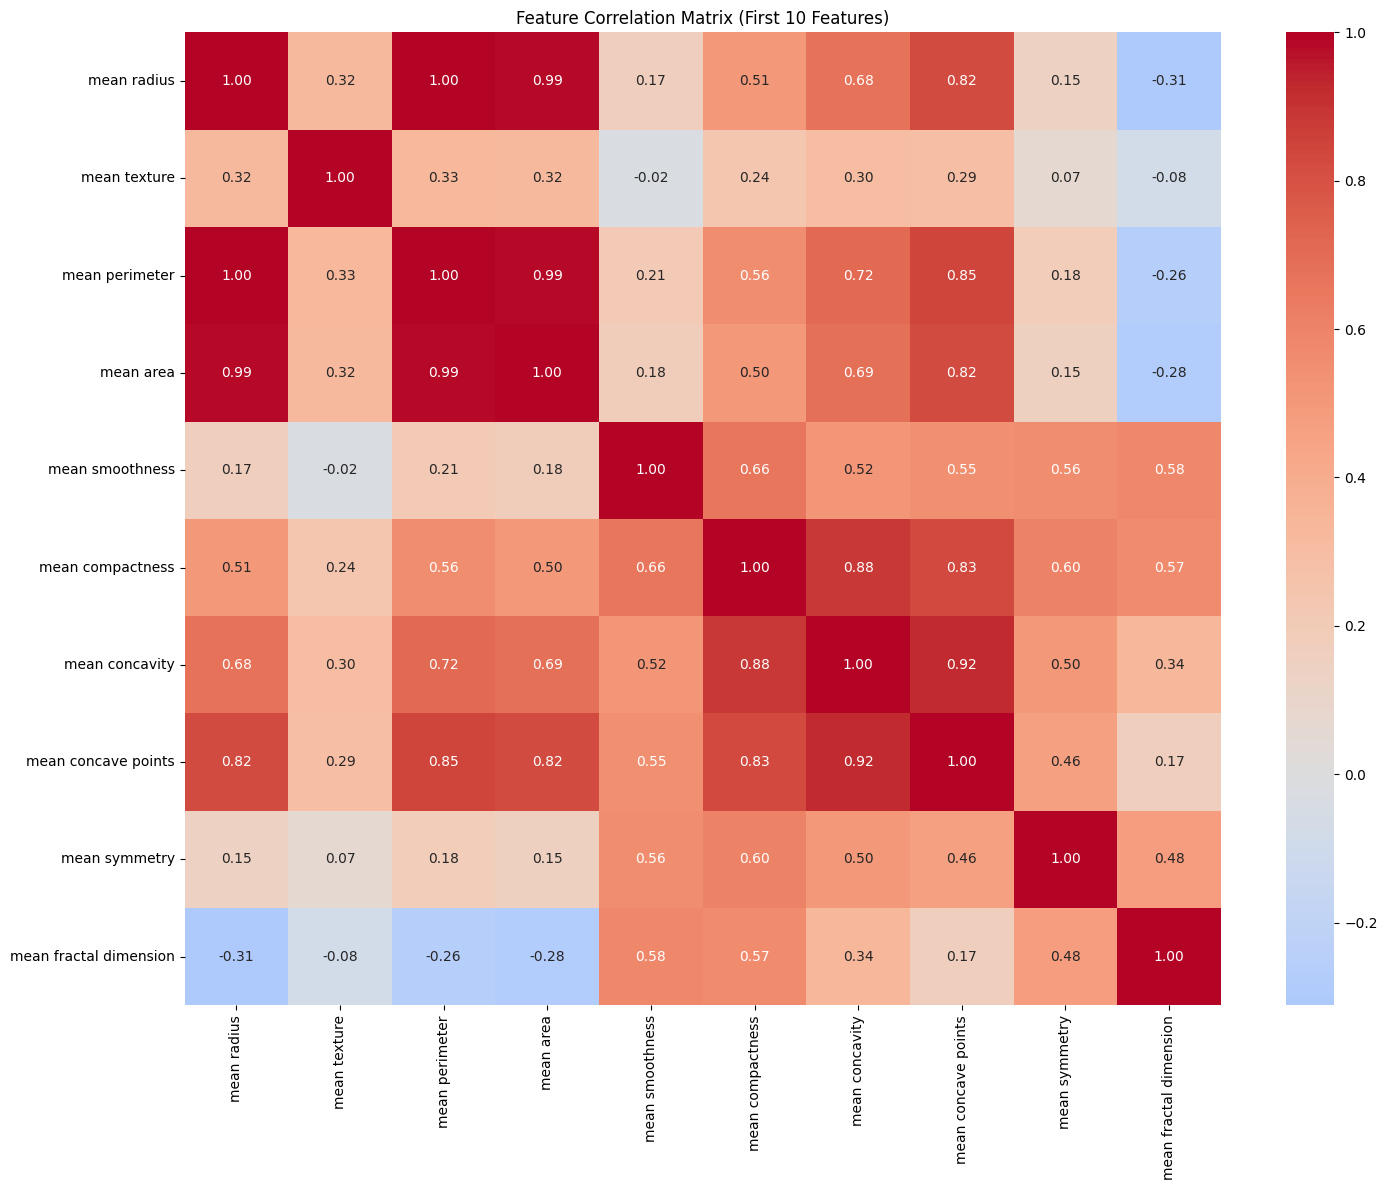

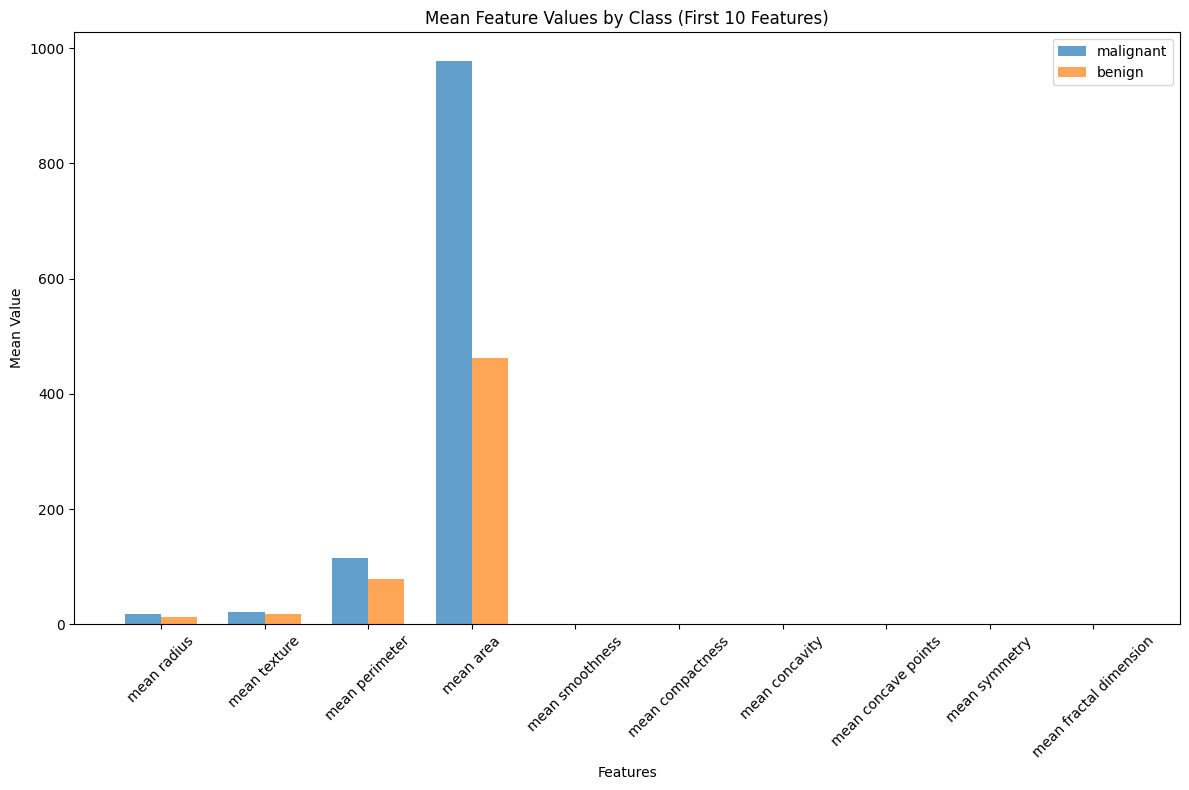

SITUATION A: 80-20 Random Split

Logistic Regression Results:
Accuracy:  0.9825
Precision: 0.9861
Recall:    0.9861
F1-Score:  0.9861

Decision Tree Results:
Accuracy:  0.9123
Precision: 0.9559
Recall:    0.9028
F1-Score:  0.9286

SITUATION B: 10-Fold Cross Validation

Logistic Regression (10-Fold CV) Results:
Accuracy:  0.9754 (+/- 0.0195)
Precision: 0.9740 (+/- 0.0339)
Recall:    0.9857 (+/- 0.0144)
F1-Score:  0.9794 (+/- 0.0176)

Decision Tree (10-Fold CV) Results:
Accuracy:  0.9350 (+/- 0.0359)
Precision: 0.9497 (+/- 0.0281)
Recall:    0.9462 (+/- 0.0392)
F1-Score:  0.9478 (+/- 0.0312)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load dataset
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target
feature_names = cancer.feature_names
target_names = cancer.target_names

print("Dataset Shape:", X.shape)
print("Classes:", target_names)

# Analysis 1: Feature Correlation Matrix
plt.figure(figsize=(15, 12))
df = pd.DataFrame(X, columns=feature_names)
# Select first 10 features for better visualization
correlation_matrix = df.iloc[:, :10].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Matrix (First 10 Features)')
plt.tight_layout()
plt.show()

# Analysis 2: Mean Features by Class
plt.figure(figsize=(12, 8))
mean_features = []
for class_label in [0, 1]:
    class_mean = X[y == class_label].mean(axis=0)
    mean_features.append(class_mean)

x_pos = np.arange(len(feature_names[:10]))  # Show first 10 features
width = 0.35

plt.bar(x_pos - width/2, mean_features[0][:10], width, label=target_names[0], alpha=0.7)
plt.bar(x_pos + width/2, mean_features[1][:10], width, label=target_names[1], alpha=0.7)

plt.xlabel('Features')
plt.ylabel('Mean Value')
plt.title('Mean Feature Values by Class (First 10 Features)')
plt.xticks(x_pos, feature_names[:10], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Preprocessing: Standardization (important for Logistic Regression)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Situation A: Random Sampling (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Initialize classifiers
lr_classifier = LogisticRegression(random_state=42, max_iter=1000)
dt_classifier = DecisionTreeClassifier(random_state=42)

print("SITUATION A: 80-20 Random Split")
print("="*60)

# Train and evaluate Logistic Regression
lr_classifier.fit(X_train, y_train)
y_pred_lr = lr_classifier.predict(X_test)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

print("\nLogistic Regression Results:")
print(f"Accuracy:  {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1-Score:  {lr_f1:.4f}")

# Train and evaluate Decision Tree
dt_classifier.fit(X_train, y_train)
y_pred_dt = dt_classifier.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

print("\nDecision Tree Results:")
print(f"Accuracy:  {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall:    {dt_recall:.4f}")
print(f"F1-Score:  {dt_f1:.4f}")

# Situation B: 10-Fold Cross Validation
print("\n" + "="*60)
print("SITUATION B: 10-Fold Cross Validation")
print("="*60)

kf = KFold(n_splits=10, shuffle=True, random_state=42)

# Logistic Regression with 10-Fold CV
lr_cv_accuracy = cross_val_score(lr_classifier, X_scaled, y, cv=kf, scoring='accuracy')
lr_cv_precision = cross_val_score(lr_classifier, X_scaled, y, cv=kf, scoring='precision')
lr_cv_recall = cross_val_score(lr_classifier, X_scaled, y, cv=kf, scoring='recall')
lr_cv_f1 = cross_val_score(lr_classifier, X_scaled, y, cv=kf, scoring='f1')

print("\nLogistic Regression (10-Fold CV) Results:")
print(f"Accuracy:  {np.mean(lr_cv_accuracy):.4f} (+/- {np.std(lr_cv_accuracy):.4f})")
print(f"Precision: {np.mean(lr_cv_precision):.4f} (+/- {np.std(lr_cv_precision):.4f})")
print(f"Recall:    {np.mean(lr_cv_recall):.4f} (+/- {np.std(lr_cv_recall):.4f})")
print(f"F1-Score:  {np.mean(lr_cv_f1):.4f} (+/- {np.std(lr_cv_f1):.4f})")

# Decision Tree with 10-Fold CV
dt_cv_accuracy = cross_val_score(dt_classifier, X_scaled, y, cv=kf, scoring='accuracy')
dt_cv_precision = cross_val_score(dt_classifier, X_scaled, y, cv=kf, scoring='precision')
dt_cv_recall = cross_val_score(dt_classifier, X_scaled, y, cv=kf, scoring='recall')
dt_cv_f1 = cross_val_score(dt_classifier, X_scaled, y, cv=kf, scoring='f1')

print("\nDecision Tree (10-Fold CV) Results:")
print(f"Accuracy:  {np.mean(dt_cv_accuracy):.4f} (+/- {np.std(dt_cv_accuracy):.4f})")
print(f"Precision: {np.mean(dt_cv_precision):.4f} (+/- {np.std(dt_cv_precision):.4f})")
print(f"Recall:    {np.mean(dt_cv_recall):.4f} (+/- {np.std(dt_cv_recall):.4f})")
print(f"F1-Score:  {np.mean(dt_cv_f1):.4f} (+/- {np.std(dt_cv_f1):.4f})")

Dataset Shape: (300, 2)
True number of clusters: 4


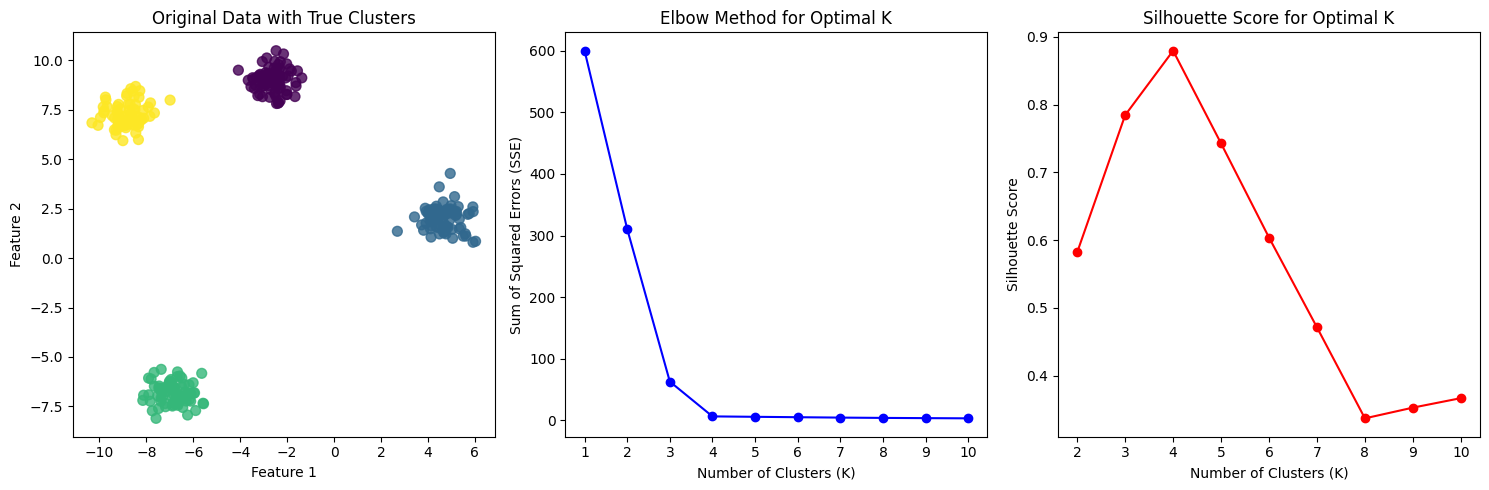

0.879591338894901


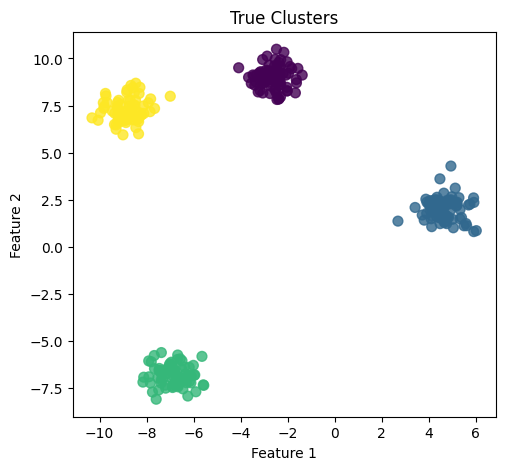

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Generate sample dataset
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=42)

# Preprocessing: Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Dataset Shape:", X.shape)
print("True number of clusters: 4")

# Plot original data
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', s=50, alpha=0.8)
plt.title('Original Data with True Clusters')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

# Method 1: Elbow Method to find optimal K
sse = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)

plt.subplot(1, 3, 2)
plt.plot(k_range, sse, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.title('Elbow Method for Optimal K')
plt.xticks(k_range)

# Method 2: Silhouette Score
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)

plt.subplot(1, 3, 3)
plt.plot(range(2, 11), silhouette_scores, 'ro-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal K')
plt.xticks(range(2, 11))

plt.tight_layout()
plt.show()

# Apply K-Means with optimal K
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
y_pred = kmeans.fit_predict(X_scaled)

# Plot clustering results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X[:,0], X[:,1], c=y_true, cmap='viridis', s=50, alpha=0.8)
plt.title('True Clusters')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
sil=silhouette_score(X_scaled, y_pred)
print(sil)


In [ ]:
print(kmeans.n_iter_)

3
